In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/parkinsons-disease-data-set/parkinsons.data


In [2]:
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler


In [3]:
df = pd.read_csv('/kaggle/input/parkinsons-disease-data-set/parkinsons.data')
df

,name,MDVP:Fo(Hz),MDVP:Fhi(Hz),MDVP:Flo(Hz),MDVP:Jitter(%),MDVP:Jitter(Abs),MDVP:RAP,MDVP:PPQ,Jitter:DDP,MDVP:Shimmer,...,Shimmer:DDA,NHR,HNR,status,RPDE,DFA,spread1,spread2,D2,PPE
0,phon_R01_S01_1,119.992,157.302,74.997,0.00784,0.00007,0.00370,0.00554,0.01109,0.04374,...,0.06545,0.02211,21.033,1,0.414783,0.815285,-4.813031,0.266482,2.301442,0.284654
1,phon_R01_S01_2,122.400,148.650,113.819,0.00968,0.00008,0.00465,0.00696,0.01394,0.06134,...,0.09403,0.01929,19.085,1,0.458359,0.819521,-4.075192,0.335590,2.486855,0.368674
2,phon_R01_S01_3,116.682,131.111,111.555,0.01050,0.00009,0.00544,0.00781,0.01633,0.05233,...,0.08270,0.01309,20.651,1,0.429895,0.825288,-4.443179,0.311173,2.342259,0.332634
3,phon_R01_S01_4,116.676,137.871,111.366,0.00997,0.00009,0.00502,0.00698,0.01505,0.05492,...,0.08771,0.01353,20.644,1,0.434969,0.819235,-4.117501,0.334147,2.405554,0.368975
4,phon_R01_S01_5,116.014,141.781,110.655,0.01284,0.00011,0.00655,0.00908,0.01966,0.06425,...,0.10470,0.01767,19.649,1,0.417356,0.823484,-3.747787,0.234513,2.332180,0.410335
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
190,phon_R01_S50_2,174.188,230.978,94.261,0.00459,0.00003,0.00263,0.00259,0.00790,0.04087,...,0.07008,0.02764,19.517,0,0.448439,0.657899,-6.538586,0.121952,2.657476,0.133050
191,phon_R01_S50_3,209.516,253.017,89.488,0.00564,0.00003,0.00331,0.00292,0.00994,0.02751,...,0.04812,0.01810,19.147,0,0.431674,0.683244,-6.195325,0.129303,2.784312,0.168895
192,phon_R01_S50_4,174.688,240.005,74.287,0.01360,0.00008,0.00624,0.00564,0.01873,0.02308,...,0.03804,0.10715,17.883,0,0.407567,0.655683,-6.787197,0.158453,2.679772,0.131728
193,phon_R01_S50_5,198.764,396.961,74.904,0.00740,0.00004,0.00370,0.00390,0.01109,0.02296,...,0.03794,0.07223,19.020,0,0.451221,0.643956,-6.744577,0.207454,2.138608,0.123306


In [4]:
df = df.drop('name', axis=1)

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 195 entries, 0 to 194
Data columns (total 23 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   MDVP:Fo(Hz)       195 non-null    float64
 1   MDVP:Fhi(Hz)      195 non-null    float64
 2   MDVP:Flo(Hz)      195 non-null    float64
 3   MDVP:Jitter(%)    195 non-null    float64
 4   MDVP:Jitter(Abs)  195 non-null    float64
 5   MDVP:RAP          195 non-null    float64
 6   MDVP:PPQ          195 non-null    float64
 7   Jitter:DDP        195 non-null    float64
 8   MDVP:Shimmer      195 non-null    float64
 9   MDVP:Shimmer(dB)  195 non-null    float64
 10  Shimmer:APQ3      195 non-null    float64
 11  Shimmer:APQ5      195 non-null    float64
 12  MDVP:APQ          195 non-null    float64
 13  Shimmer:DDA       195 non-null    float64
 14  NHR               195 non-null    float64
 15  HNR               195 non-null    float64
 16  status            195 non-null    int64  
 1

In [6]:
df.isnull().sum()

MDVP:Fo(Hz)         0
MDVP:Fhi(Hz)        0
MDVP:Flo(Hz)        0
MDVP:Jitter(%)      0
MDVP:Jitter(Abs)    0
MDVP:RAP            0
MDVP:PPQ            0
Jitter:DDP          0
MDVP:Shimmer        0
MDVP:Shimmer(dB)    0
Shimmer:APQ3        0
Shimmer:APQ5        0
MDVP:APQ            0
Shimmer:DDA         0
NHR                 0
HNR                 0
status              0
RPDE                0
DFA                 0
spread1             0
spread2             0
D2                  0
PPE                 0
dtype: int64

<Axes: xlabel='status', ylabel='values'>

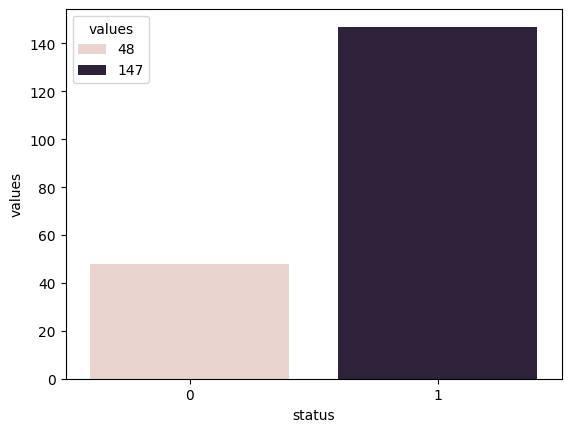

In [7]:
temp = df['status'].value_counts()
temp_df = pd.DataFrame({'status':temp.index,'values':temp.values})
sns.barplot(x='status',y='values',data=temp_df,hue='values')


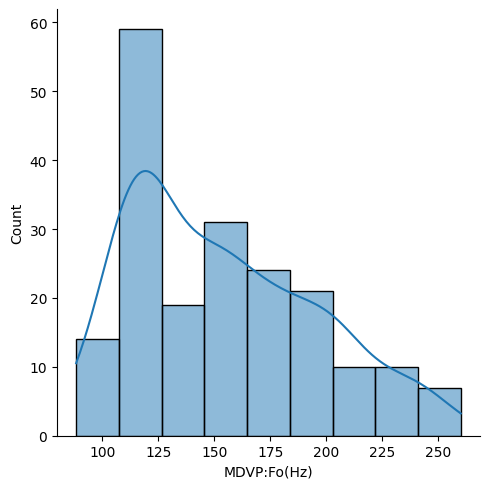

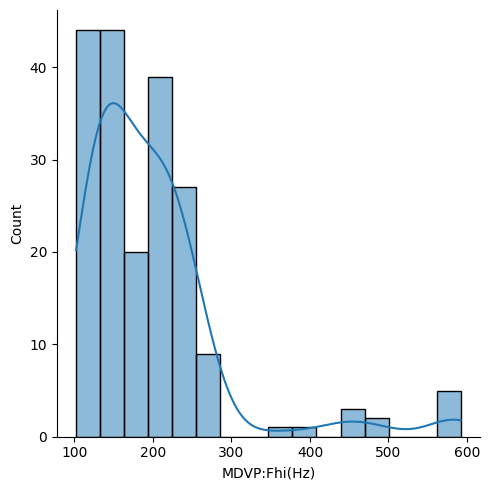

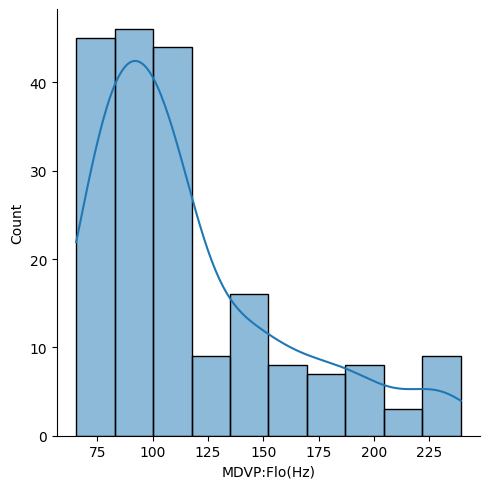

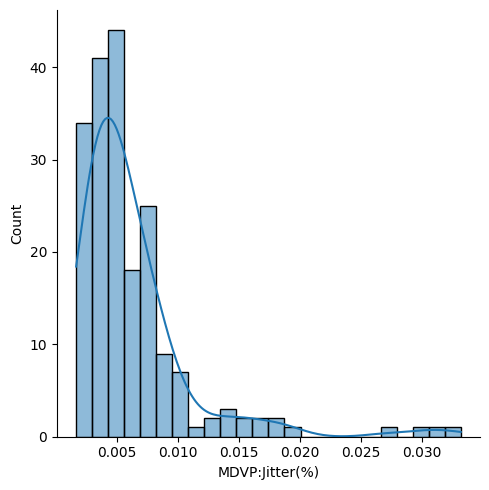

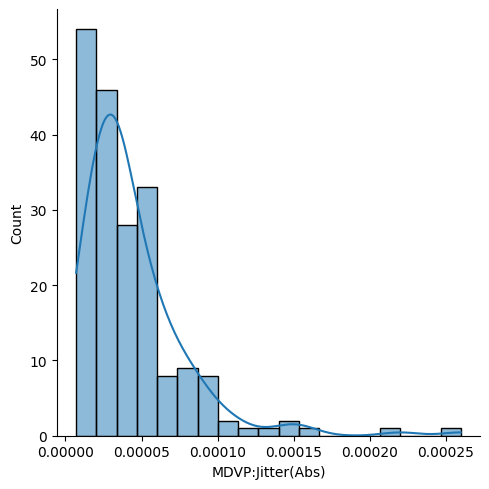

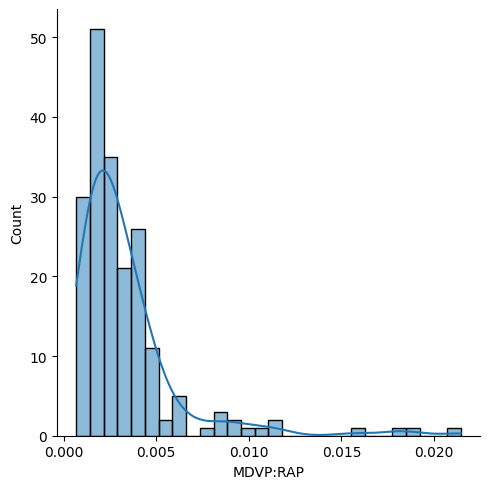

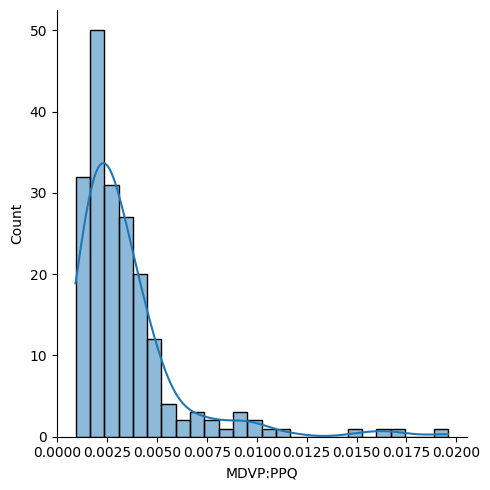

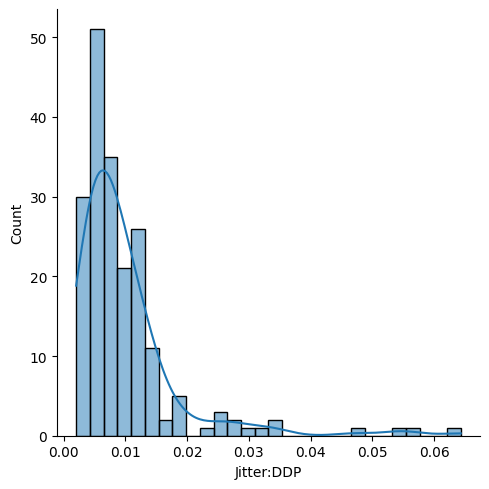

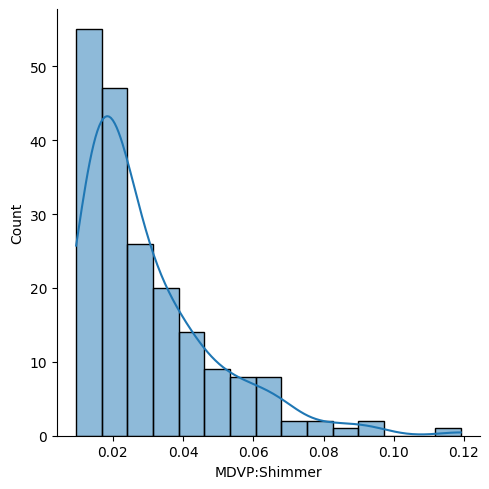

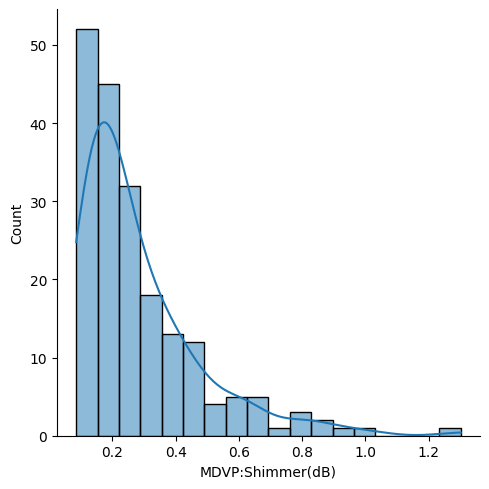

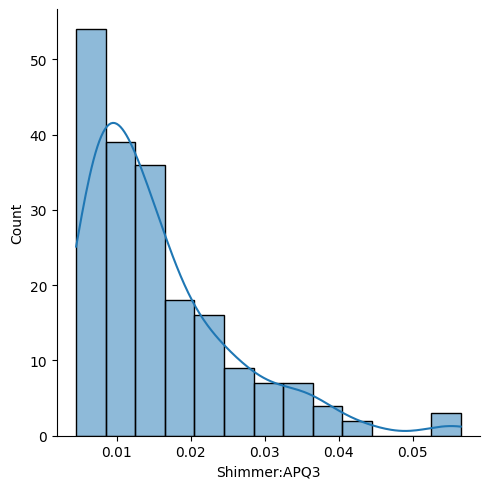

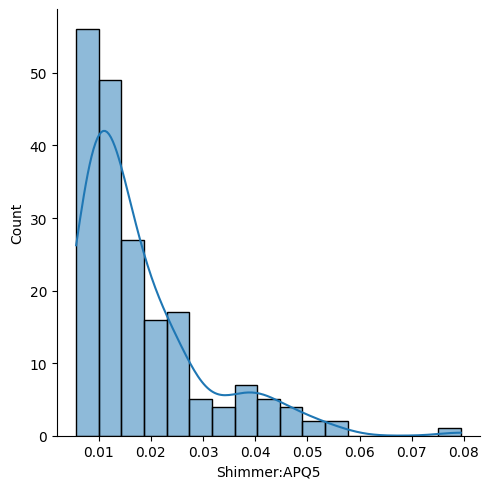

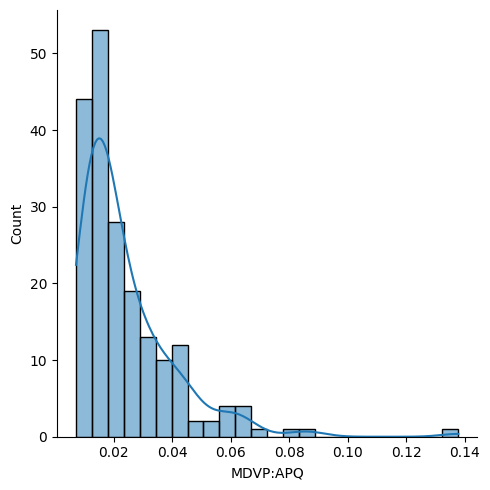

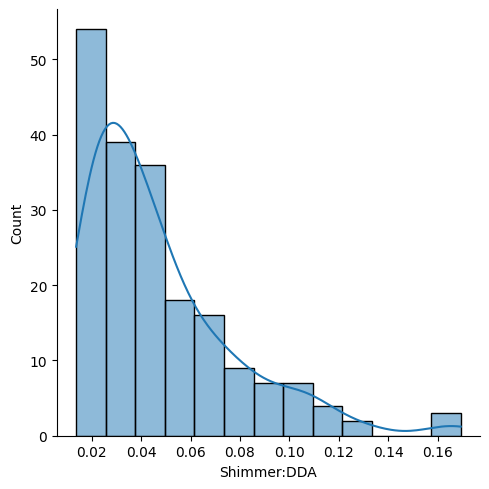

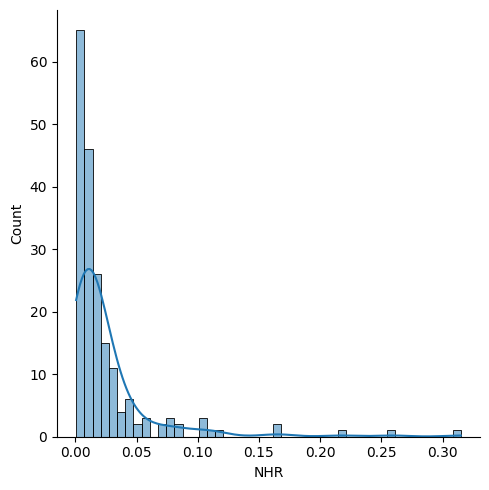

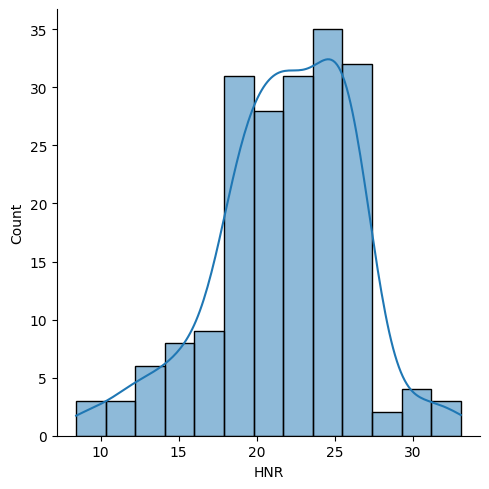

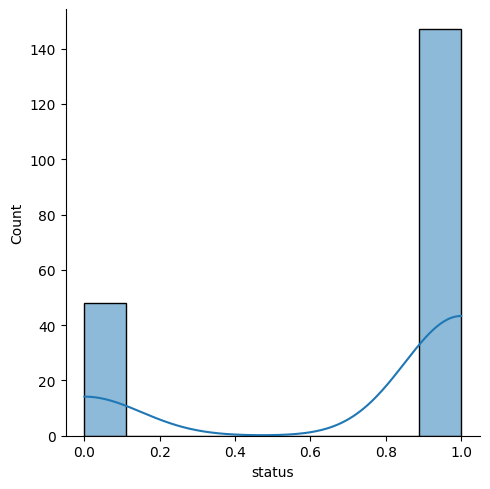

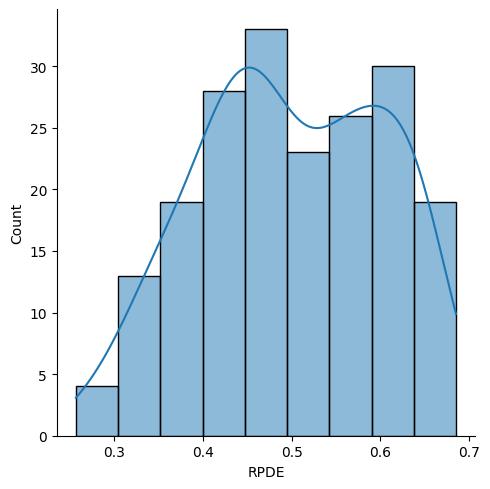

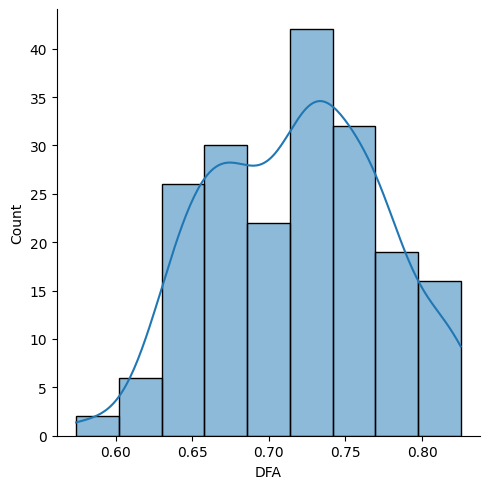

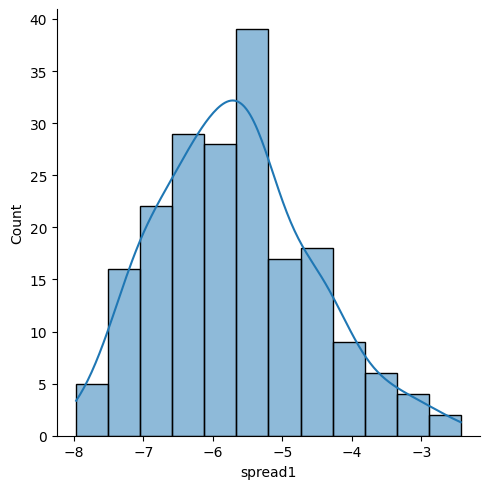

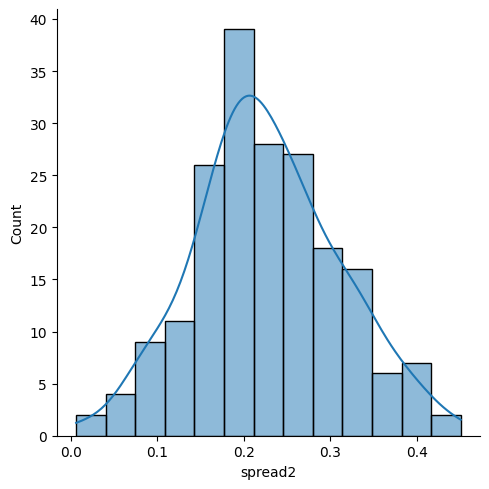

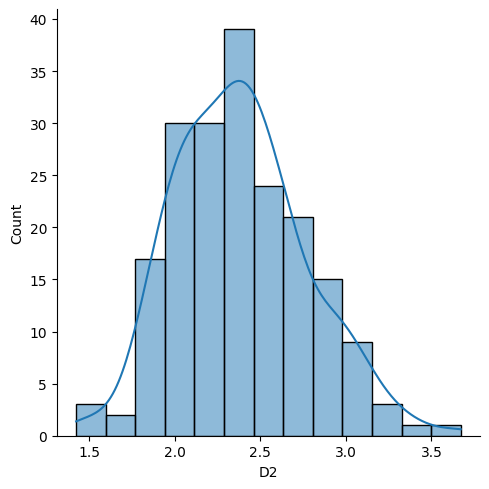

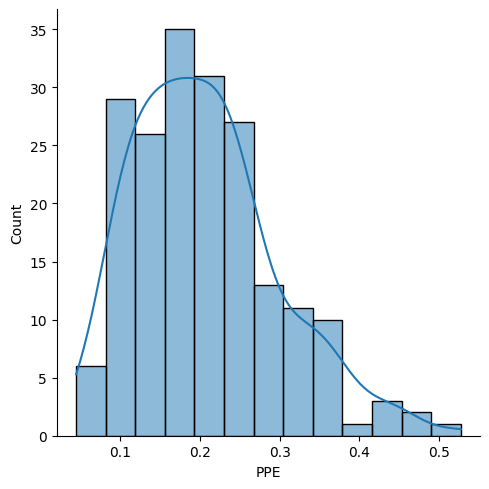

In [8]:
def distplots(col):
    sns.displot(df[col],kde = True)
    plt.show()

for i in list(df.columns):
    distplots(i)
    

<Axes: >

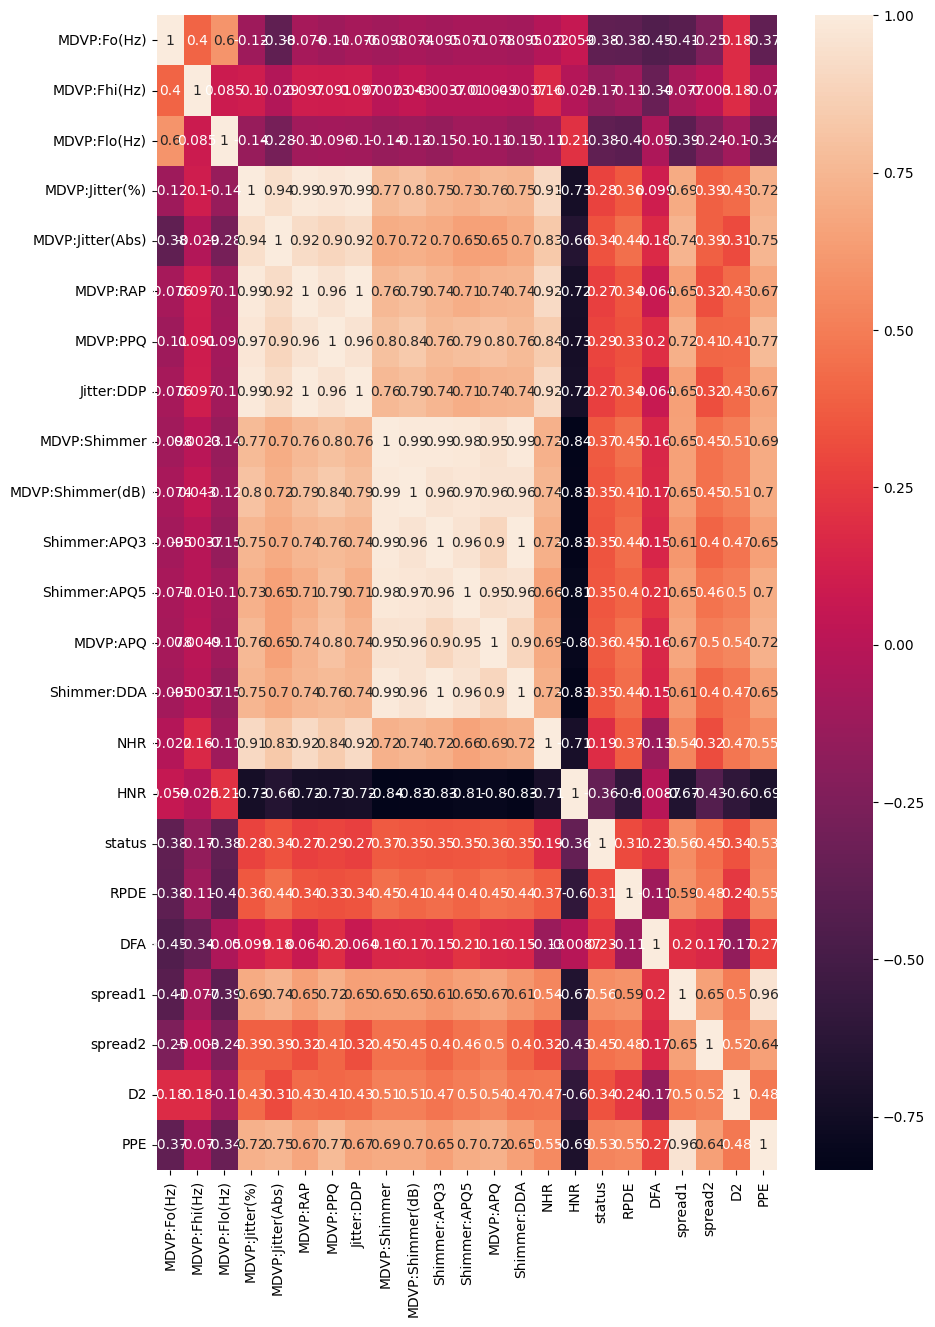

In [9]:
plt.figure(figsize=(10,15))
corr=df.corr()
sns.heatmap(corr,annot=True)

In [10]:
X = df.drop('status',axis=1)
y = df['status']

In [11]:
import imblearn
from imblearn.over_sampling import RandomOverSampler
from imblearn.under_sampling import RandomUnderSampler
from collections import Counter

print(Counter(y))

Counter({1: 147, 0: 48})


In [12]:
ros = RandomOverSampler()

X_ros , y_ros = ros.fit_resample(X,y)
print(Counter(y_ros))

Counter({1: 147, 0: 147})


In [13]:
scaler = MinMaxScaler((-1,1))
x_scaler=scaler.fit_transform(X_ros)
y_scaler=y_ros

In [14]:
from sklearn.decomposition import PCA

pca = PCA(.95)
X_pca = pca.fit_transform(x_scaler)

print(x_scaler.shape)
print(X_pca.shape)

(294, 22)
(294, 8)


In [15]:
X_train , X_test , y_train , y_test = train_test_split(X_pca,y_scaler,test_size=0.2,random_state = 7)

In [16]:
from sklearn.metrics import confusion_matrix, accuracy_score, f1_score, precision_score, recall_score


In [17]:
list_met = []
list_accuracy=[]

In [18]:
from sklearn.linear_model import LogisticRegression

classifier = LogisticRegression(C=0.4, max_iter=1000, solver='liblinear')
lr = classifier.fit(X_train, y_train)
y_pred = classifier.predict(X_test)
accuracy_LR = accuracy_score(y_test, y_pred)

accuracy_LR = accuracy_score(y_test , y_pred)

from sklearn.tree import DecisionTreeClassifier

classifier2 = DecisionTreeClassifier(random_state=24)
dt = classifier2.fit(X_train, y_train)
y_pred2 = classifier2.predict(X_test)
accuracy_dt = accuracy_score(y_test, y_pred2)

accuracy_dt = accuracy_score(y_test,y_pred2)

from sklearn.ensemble import RandomForestClassifier

classifier3 = RandomForestClassifier(random_state=24)
rf = classifier3.fit(X_train, y_train)
y_pred3 = classifier3.predict(X_test)
accuracy_rf = accuracy_score(y_test, y_pred3)

accuracy_dt = accuracy_score(y_test,y_pred3)




In [19]:
results = pd.DataFrame({
    'Model': ['Logistic Regression', 'Decision Tree', 'Random Forest'],
    'Accuracy': [accuracy_LR, accuracy_dt, accuracy_rf]
}).sort_values(by='Accuracy', ascending=False)

print(results)

                 Model  Accuracy
1        Decision Tree   1.00000
2        Random Forest   1.00000
0  Logistic Regression   0.79661
